# Random Forest Classification

* ensemble method random forest classification is an ensemble supervised machine learning algorithm. The algorithm aggregates the results of several simple estimators in order to produce results built upon decision trees. 

* We will be building a model to classify our data utilzing the irish rental data set in order to ascertain if we can clasify each of the three price categories (Budget, Standard and Luxury). THis model will be built without the inclusion of rent price and land to rent  as rental prices were used to establish the current pricing strategy and including them would lead to data leakage.

* We are doing this in order to evaluate the effectiveness of our other socioeconomic and property variables in determining a property's price classification. We hope this will provide insight into which factors are most influential in predicting rental price categories across Irish counties, thus allowing our business to price properties more effectively.

# 1) Imports 

In [1]:
#Group assignment random forest classification
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import joblib 
import pickle



In [2]:
import os
print(os.getcwd())

/Users/jackburke/anaconda_projects/Group_Assignment


In [3]:
#Import csv file
dataset = pd.read_csv("Data_with_class.csv")

dataset_clean = dataset.drop(columns= ['Unnamed: 0.1', 'Unnamed: 0'])




In [4]:
dataset_clean.head()

,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Average_Value_County,Rent_To_Land_Ratio,Average_Value_Bedroom_Count,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,Standard,Four plus bed,Carlow,1397.92,17417,61968,976.857368,0.080262,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
1,Standard,Four plus bed,Carlow,1323.98,17417,61968,976.857368,0.076017,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
2,Standard,All bedrooms,Carlow,1060.03,17417,61968,976.857368,0.060862,1029.973333,86.53,147.83,25.62,33.55,7.19,53953
3,Standard,Three bed,Carlow,1028.83,17417,61968,976.857368,0.059070,1002.910000,86.53,147.83,25.62,33.55,7.19,53953
4,Standard,All bedrooms,Carlow,1017.06,17417,61968,976.857368,0.058395,1029.973333,86.53,147.83,25.62,33.55,7.19,53953


# 2) Data preparation 

* Several key steps need to be taken in order to adequately prepare our data before we build our model.


* Firstly the categorical variables within the dataset (Price_Category, Number of Bedrooms and County) all must be encoded in order for the decision tree model to work. This is done by label encoding price and bedrooms and binary coding county, these two methods are used as label encoding establishes a hierarchy e.g. Luxury > Standard whereas binary encoding does not allowing for each county to be represneted without affecting our model
 
* The next step is establishing our x and y values for our model. y being the tagrte variable we use .iloc to select the values of price category and no other values. As explained above we have to exclude rental categories and price_category we cannot use iloc to capture values we must instead drop the columns from our data frame . Aside from that all other variables within the dataset will be used in order to craft the most accurate model possible

In [5]:
#Encoding the categorical variables (Price_category, Number of bedrooms and County)
#Price categories and number of bedrooms will be label encoded
#Counties will be binary encoded as to not establish an ordering 

le_price = LabelEncoder()
le_bedrooms = LabelEncoder()

dataset_clean['Price_Category'] = le_price.fit_transform(dataset_clean['Price_Category'])
dataset_clean['Number of Bedrooms'] = le_bedrooms.fit_transform(dataset_clean['Number of Bedrooms'])


#Binary encoding    
dataset_clean = pd.get_dummies(dataset_clean, columns=['County'])

In [6]:
#Establishing taregt and predictor variables cant use iloc on x cleanly because of rent 
y = dataset_clean.iloc[:,0].values
x = dataset_clean.drop(columns=['Price_Category', 'Rent_Price', 'Rent_To_Land_Ratio', 'vat_internal_€m', 'self_employed_income_tax_€m', 'corporation_tax_€m', 'capital_gains_tax_€m'])

In [7]:
x = x.reindex(sorted(x.columns), axis = 1)

In [8]:
print(dataset_clean['Number of Bedrooms'].unique())

[3 2 5 1 6 0 4]


# 3) Model building 

* Following this I established my training and testing split having 80% training data split and 20% of the data being used to test the model and using random state 48 to ensure reproduceability of my model.

* The data was then scaled using standard scaler in order for our predictor variables to have equal bearing on the model, scaling the x testing and training data. 

* Following this we establish our classifier model using random forrest classifier from sckikitlearn, our modle will use 200 estimators in order to create an effective model without overfitting, the classfifier is then fit with the x and y training data and our y_pred is established


In [9]:
#The dataset must then be split into training and testing sets so the model is trained and then tested on unseen data
X_train , X_test, Y_train, Y_test = train_test_split(x, y, test_size= 0.25, random_state= 0, stratify= y )
X_test_df = X_test.copy()

In [10]:
#Scale data to ensure all features are on a similar scale 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
#Building classification model 
Classifier = RandomForestClassifier(n_estimators = 200, random_state = 48)
Classifier.fit(X_train,Y_train)
y_pred = Classifier.predict(X_test)

In [12]:
#Export Model

model_filename = 'Random_forest_classifier_model.pkl'
scaler_filename = 'Random_forest_scaler_model.pkl'
joblib.dump(Classifier, model_filename)
joblib.dump(scaler,scaler_filename)

print(f"Model save to file: " + model_filename)
print(f"Scaler Saved to File: " + scaler_filename)

Model save to file: Random_forest_classifier_model.pkl
Scaler Saved to File: Random_forest_scaler_model.pkl


# 4) Model Perfromance testing 

* Following the building of our model we can test the accuracy score of our model comparimng how the algorithm allocates each price category based on what it predicts compared to the actual price category.The Aaccuracy score of this model is 77% accurated. If relevant data is presented to this model it will accurately predict the price category. 

* A confusion matrix was printed to vizualize how each category of labels were classified. The model seemed to have the most difficulty identifying standard residencies and it classified standard residencies wrong 58 times.

* A bar graph identifying the importance of each feature with the average value per county, population of county and number of bedrooms being the most prominent features of our random forest model.

Accuracy: 78.63%


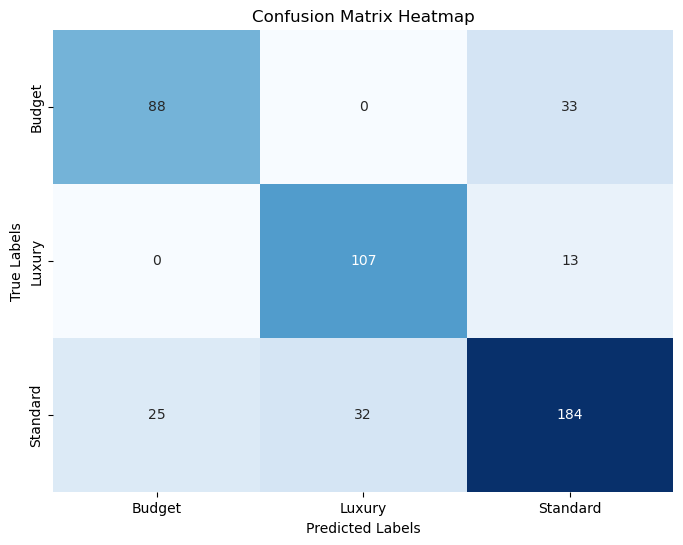

In [13]:
#Testing model perfromance 
accuracy = accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
conf_matrix = confusion_matrix(Y_test, y_pred)

#Plotting accuracy using confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
             xticklabels=le_price.classes_, yticklabels=le_price.classes_)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

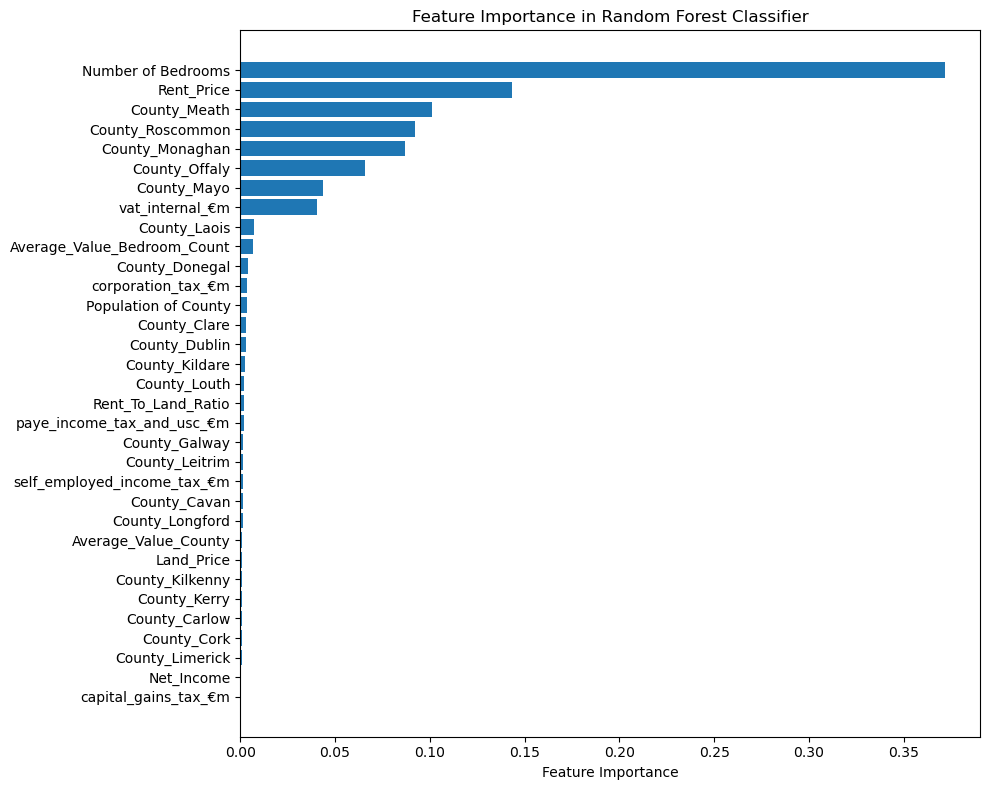

In [14]:
#Graphing feature importance 
feature_importances = Classifier.feature_importances_
feature_names = dataset_clean.drop(columns=['Price_Category']).columns

#Graph
indices = np.argsort(feature_importances)

plt.figure(figsize=(10, 8))
plt.barh(feature_names[indices], feature_importances[indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()
plt.show()

# 5) Model Validation 

* We can test the validation of our model using cross fold validation in which we get the mean value of each validation score to identify how the model perfroms across different subsets of the data. 10 folds of cross validation idicates our data is split into 10 seperate subsets. 

* The 10-fold cross validation returned a mean score of 49.95% which sits much lower than the 77% model accuracy score, this is caused by the structure of the data being split by county causing some counties to appear in training data that doesnt apply to the test data

* The accuracy score is the more reliable figure due to the structure of testing

In [15]:

scores = cross_val_score(Classifier, x, y, cv=10)

print(f'Cross Validation Scores: {scores}')
print(f'Mean Accuracy: {scores.mean() * 100:.2f}%')
print(f'Standard Deviation: {scores.std() * 100:.2f}%')

Cross Validation Scores: [0.82901554 0.68393782 0.49740933 0.53367876 0.39378238 0.36458333
 0.36458333 0.203125   0.484375   0.640625  ]
Mean Accuracy: 49.95%
Standard Deviation: 17.30%


# 6) Logistic Regression and Random Forest Model Comparison and Business use

* Both models achieve very similar accuracy scores, Logistic Regression at 78.01% and Random Forrest at 78.63%. 

* Regarding the confusion matrices, the key difference is in how each model handles the budget tier. Logistic Regression correctly identifies 107 of 121 Budget properties, random forest only gets 88, misclassifying 33 as standard. 

* However, random forest does perform better on standard, correctly identifying 184 of 241 compared to logistic regression's 162. both models perform the same on luxury with 107 correct.

* In conclusion, Random Forrest achieves a marginally better accuracy score and performs better on standard, while logistic regression performs better on budget classification. For our business use case, random forest is the stronger performing model here as it has a slightly higher accuracy score and correctly classifies more standard properties, which would be the largest and most commercially common tier. 

* Logistic regression is still useful. This is because it achieves nearly an identical accuracy score to random forest and is significantly faster to train and easier to update as new data becomes available. 



In [18]:
Logistic_model = joblib.load('Logistic_Regression_Classifier_model_final.pkl')
Logistic_scaler = joblib.load('Logistic_Regression_Scaler_final.pkl')

X_test_lr = Logistic_scaler.transform(X_test_df)

lr_pred = Logistic_model.predict(X_test_lr)

#Compare 
print('--- Logistic Regression ---') 
print('Accuracy:', round(accuracy_score(Y_test, lr_pred), 4)) 


print('--- Random Forest ---') 
print('Accuracy:', round(accuracy_score(Y_test, y_pred), 4)) 


--- Logistic Regression ---
Accuracy: 0.7801
--- Random Forest ---
Accuracy: 0.7863


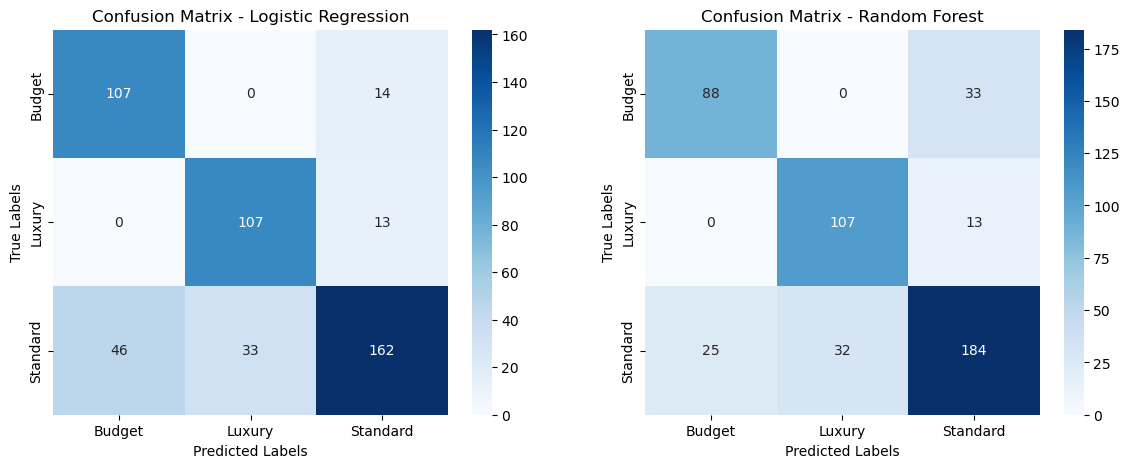

In [19]:
labels = ['Budget', 'Luxury', 'Standard']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(Y_test, lr_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
plt.sca(axes[0])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
plt.sca(axes[1])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()